In [19]:
from pathlib import Path

base = Path("monitoring") / "1831_nomirror_16t_80G"



/tmp/ipykernel_1294/1306217442.py:249: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


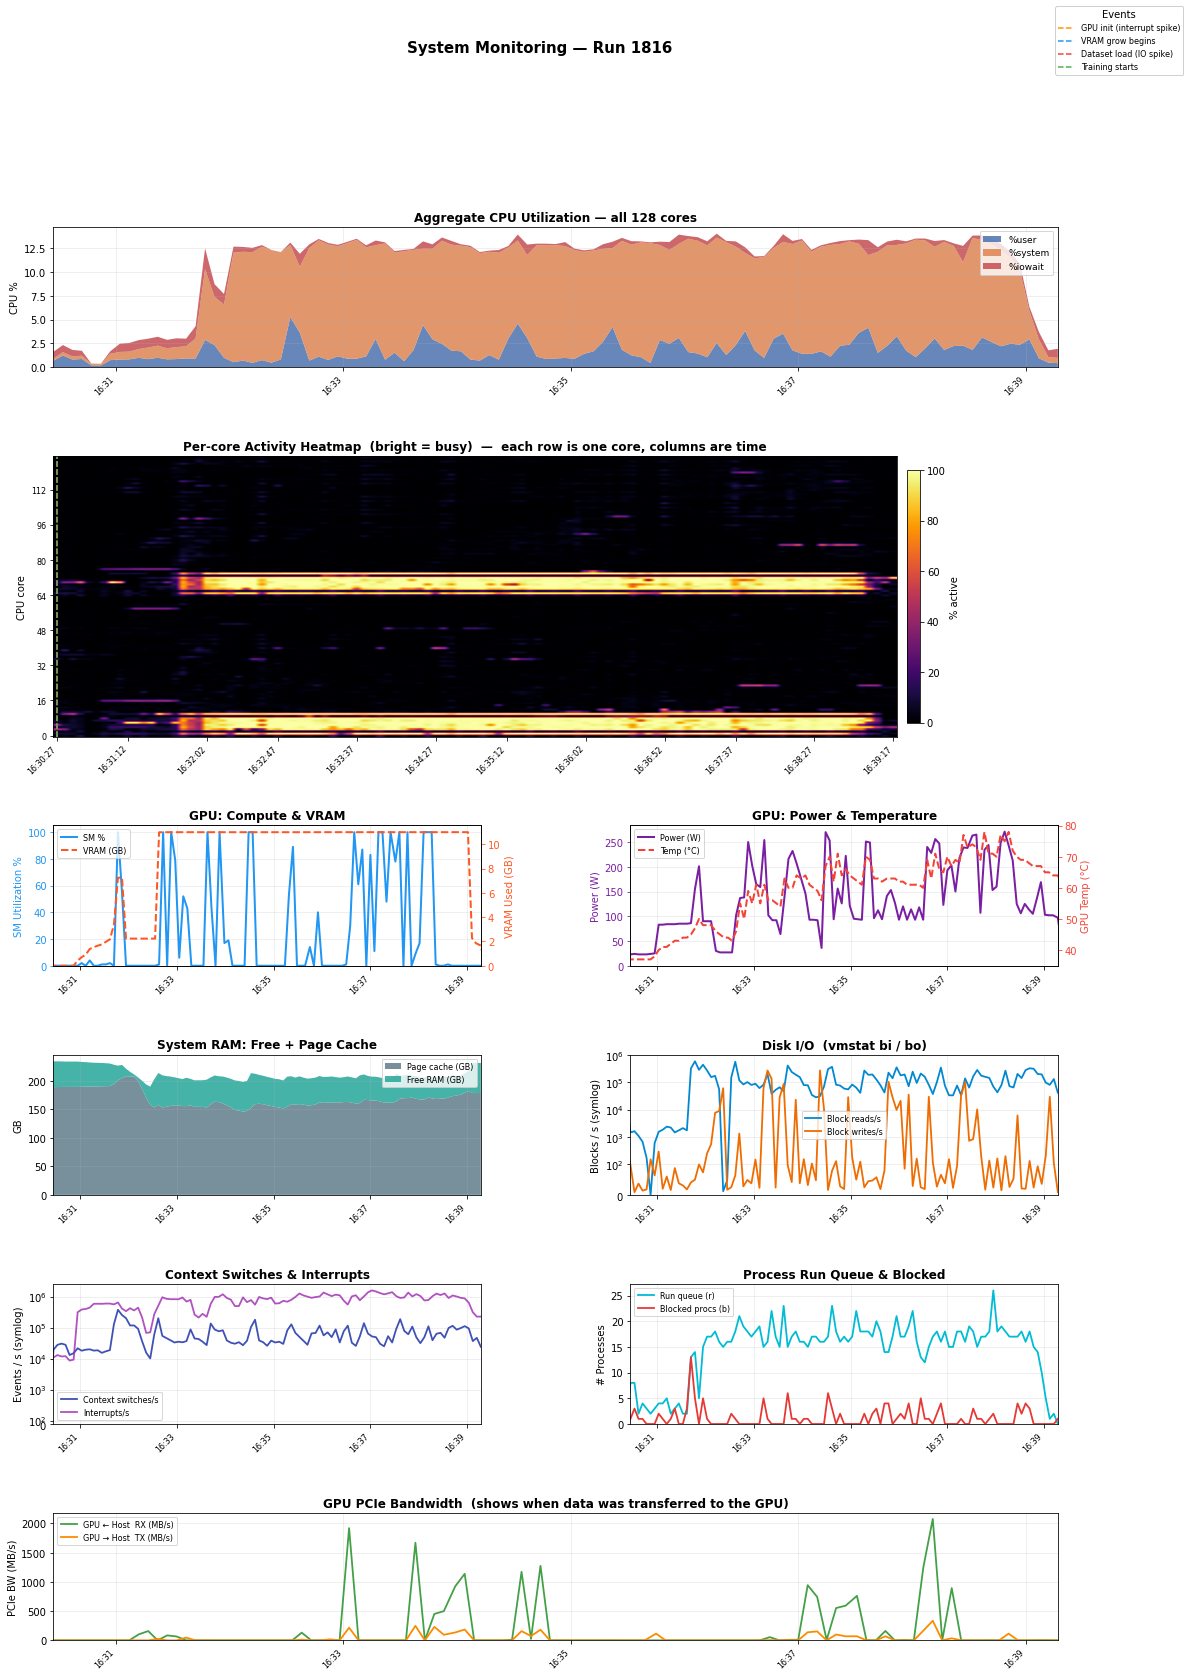

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.dates as mdates
from pathlib import Path

# ── 1. Parse CPU log (mpstat) ─────────────────────────────────────────────────
cpu_records = []
date_str = None
with open(base / "cpu_util.log") as f:
    for line in f:
        parts = line.split()
        if date_str is None:              # grab date from first line header
            for p in parts:
                if "/" in p and len(p) == 10:
                    date_str = p
                    break
        if len(parts) < 9 or parts[2] == "CPU":
            continue
        try:
            ts = pd.to_datetime(
                f"{date_str} {parts[0]} {parts[1]}", format="%m/%d/%Y %I:%M:%S %p"
            )
            cpu = parts[2]
            user, nice, system, iowait, steal, idle = map(float, parts[3:9])
            cpu_records.append({
                "time": ts, "cpu": cpu,
                "user": user, "system": system, "iowait": iowait,
                "idle": idle, "active": 100 - idle,
            })
        except (ValueError, IndexError):
            continue

cpu_df  = pd.DataFrame(cpu_records)
cpu_agg = cpu_df[cpu_df["cpu"] == "all"].set_index("time").sort_index()
cpu_per = cpu_df[cpu_df["cpu"] != "all"].copy()
cpu_per["cpu"] = cpu_per["cpu"].astype(int)

# ── 2. Parse GPU log (dcgmi) ───────────────────────────────────────────────────
gpu_df = pd.read_csv(
    base / "gpu_util.log",
    comment="#", sep=r"\s+", header=None, na_values=["-"],
    names=["date", "time", "gpu", "sm", "mem_pct", "enc", "dec", "jpg",
           "ofa", "pwr", "gtemp", "mtemp", "fb_mb", "bar1", "ccpm", "rxpci", "txpci"],
)
gpu_df["time"] = pd.to_datetime(
    gpu_df["date"].astype(str) + " " + gpu_df["time"], format="%Y%m%d %H:%M:%S"
)
gpu_df = gpu_df.set_index("time").sort_index()
gpu_df["fb_gb"] = gpu_df["fb_mb"] / 1024

# ── 3. Parse memory log (vmstat) ──────────────────────────────────────────────
mem_records = []
with open(base / "memory.log") as f:
    for line in f:
        parts = line.split()
        if len(parts) < 18 or not parts[0].isdigit():
            continue
        try:
            ts = pd.to_datetime(f"{parts[-2]} {parts[-1]}")
            mem_records.append({
                "time": ts,
                "r": int(parts[0]),  "b": int(parts[1]),
                "free_gb":  int(parts[3]) / 1024**2,
                "cache_gb": int(parts[5]) / 1024**2,
                "bi": int(parts[8]),  "bo": int(parts[9]),
                "interrupts": int(parts[10]),  "cs": int(parts[11]),
            })
        except (ValueError, IndexError):
            continue

mem_df = pd.DataFrame(mem_records).set_index("time").sort_index()

# ── 4. Annotated events (inferred from data spikes) ───────────────────────────
events = {
    pd.Timestamp("2026-04-22 12:08:59"): ("GPU init\n(interrupt spike)", "#FF9800"),
    pd.Timestamp("2026-04-22 12:09:04"): ("VRAM grow\nbegins",           "#2196F3"),
    pd.Timestamp("2026-04-22 12:09:49"): ("Dataset load\n(IO spike)",    "#F44336"),
    pd.Timestamp("2026-04-22 12:09:54"): ("Training\nstarts",            "#4CAF50"),
}

def add_events(ax, label_y=0.97, fontsize=7):
    for t, (label, color) in events.items():
        ax.axvline(t, color=color, lw=1.2, ls="--", alpha=0.8)

def fmt_time(ax):
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
    ax.xaxis.set_major_locator(mdates.MinuteLocator(interval=2))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha="right", fontsize=8)
    ax.set_xlim(cpu_agg.index[0], cpu_agg.index[-1])

# ── 5. Build dashboard ────────────────────────────────────────────────────────
fig = plt.figure(figsize=(18, 26))
gs  = gridspec.GridSpec(
    6, 2, figure=fig, hspace=0.55, wspace=0.35,
    height_ratios=[1.1, 2.2, 1.1, 1.1, 1.1, 1.0],
)

# ── A: Aggregate CPU (full width) ─────────────────────────────────────────────
ax_cpu = fig.add_subplot(gs[0, :])
ax_cpu.stackplot(
    cpu_agg.index, cpu_agg["user"], cpu_agg["system"], cpu_agg["iowait"],
    labels=["%user", "%system", "%iowait"],
    colors=["#4C72B0", "#DD8452", "#C44E52"], alpha=0.85,
)
ax_cpu.set_ylabel("CPU %"); ax_cpu.set_ylim(bottom=0)
ax_cpu.set_title("Aggregate CPU Utilization — all 128 cores", fontweight="bold")
ax_cpu.legend(loc="upper right", fontsize=9)
ax_cpu.grid(True, alpha=0.25)
add_events(ax_cpu)
fmt_time(ax_cpu)

# ── B: Per-core heatmap (full width) ──────────────────────────────────────────
ax_heat = fig.add_subplot(gs[1, :])
pivot = (
    cpu_per.groupby(["cpu", "time"])["active"]
    .first().unstack("time").sort_index()
)
im = ax_heat.imshow(
    pivot.values, aspect="auto", cmap="inferno",
    vmin=0, vmax=100, origin="lower",
)
fig.colorbar(im, ax=ax_heat, label="% active", pad=0.01, shrink=0.9)
ax_heat.set_ylabel("CPU core")
ax_heat.set_title(
    "Per-core Activity Heatmap  (bright = busy)  —  each row is one core, columns are time",
    fontweight="bold",
)
n_cols   = pivot.shape[1]
tick_pos = np.linspace(0, n_cols - 1, 12, dtype=int)
ax_heat.set_xticks(tick_pos)
ax_heat.set_xticklabels(
    [pivot.columns[i].strftime("%H:%M:%S") for i in tick_pos],
    rotation=45, ha="right", fontsize=8,
)
ax_heat.set_yticks(np.arange(0, 128, 16))
ax_heat.set_yticklabels([str(i) for i in range(0, 128, 16)], fontsize=8)
# draw event lines mapped to heatmap column indices
for t, (_, color) in events.items():
    nearest = np.searchsorted(pivot.columns, t)
    if 0 <= nearest < n_cols:
        ax_heat.axvline(nearest, color=color, lw=1.5, ls="--", alpha=0.9)

# ── C: GPU compute & VRAM (left) ──────────────────────────────────────────────
ax_sm = fig.add_subplot(gs[2, 0])
ax_fb = ax_sm.twinx()
ax_sm.plot(gpu_df.index, gpu_df["sm"],   color="#2196F3", label="SM %",      lw=2)
ax_fb.plot(gpu_df.index, gpu_df["fb_gb"], color="#FF5722", label="VRAM (GB)", lw=2, ls="--")
ax_sm.set_ylabel("SM Utilization %", color="#2196F3")
ax_fb.set_ylabel("VRAM Used (GB)",   color="#FF5722")
ax_sm.set_title("GPU: Compute & VRAM", fontweight="bold")
ax_sm.tick_params(axis="y", colors="#2196F3")
ax_fb.tick_params(axis="y", colors="#FF5722")
ax_sm.set_ylim(bottom=0); ax_fb.set_ylim(bottom=0)
ax_sm.grid(True, alpha=0.25)
h1, l1 = ax_sm.get_legend_handles_labels()
h2, l2 = ax_fb.get_legend_handles_labels()
ax_sm.legend(h1 + h2, l1 + l2, fontsize=8, loc="upper left")
add_events(ax_sm); fmt_time(ax_sm)

# ── D: GPU power & temperature (right) ────────────────────────────────────────
ax_pwr = fig.add_subplot(gs[2, 1])
ax_tmp = ax_pwr.twinx()
ax_pwr.plot(gpu_df.index, gpu_df["pwr"],   color="#7B1FA2", label="Power (W)",  lw=2)
ax_tmp.plot(gpu_df.index, gpu_df["gtemp"], color="#F44336", label="Temp (°C)",  lw=2, ls="--")
ax_pwr.set_ylabel("Power (W)",    color="#7B1FA2")
ax_tmp.set_ylabel("GPU Temp (°C)", color="#F44336")
ax_pwr.set_title("GPU: Power & Temperature", fontweight="bold")
ax_pwr.tick_params(axis="y", colors="#7B1FA2")
ax_tmp.tick_params(axis="y", colors="#F44336")
ax_pwr.set_ylim(bottom=0)
ax_pwr.grid(True, alpha=0.25)
h1, l1 = ax_pwr.get_legend_handles_labels()
h2, l2 = ax_tmp.get_legend_handles_labels()
ax_pwr.legend(h1 + h2, l1 + l2, fontsize=8, loc="upper left")
add_events(ax_pwr); fmt_time(ax_pwr)

# ── E: System RAM — free + page cache (left) ──────────────────────────────────
ax_ram = fig.add_subplot(gs[3, 0])
ax_ram.stackplot(
    mem_df.index, mem_df["cache_gb"], mem_df["free_gb"],
    labels=["Page cache (GB)", "Free RAM (GB)"],
    colors=["#607D8B", "#26A69A"], alpha=0.85,
)
ax_ram.set_ylabel("GB"); ax_ram.set_ylim(bottom=0)
ax_ram.set_title("System RAM: Free + Page Cache", fontweight="bold")
ax_ram.legend(fontsize=8)
ax_ram.grid(True, alpha=0.25)
add_events(ax_ram); fmt_time(ax_ram)

# ── F: Disk I/O (right) ───────────────────────────────────────────────────────
ax_io = fig.add_subplot(gs[3, 1])
ax_io.plot(mem_df.index, mem_df["bi"], label="Block reads/s",  color="#0288D1", lw=1.8)
ax_io.plot(mem_df.index, mem_df["bo"], label="Block writes/s", color="#EF6C00", lw=1.8)
ax_io.set_ylabel("Blocks / s (symlog)")
ax_io.set_title("Disk I/O  (vmstat bi / bo)", fontweight="bold")
ax_io.legend(fontsize=8)
ax_io.set_yscale("symlog", linthresh=100)
ax_io.set_ylim(bottom=0)
ax_io.grid(True, alpha=0.25)
add_events(ax_io); fmt_time(ax_io)

# ── G: Context switches & interrupts (left) ───────────────────────────────────
ax_cs = fig.add_subplot(gs[4, 0])
ax_cs.plot(mem_df.index, mem_df["cs"],         label="Context switches/s", color="#3F51B5", lw=1.8)
ax_cs.plot(mem_df.index, mem_df["interrupts"], label="Interrupts/s",       color="#9C27B0", lw=1.8, alpha=0.8)
ax_cs.set_ylabel("Events / s (symlog)")
ax_cs.set_title("Context Switches & Interrupts", fontweight="bold")
ax_cs.legend(fontsize=8)
ax_cs.set_yscale("symlog", linthresh=1000)
ax_cs.set_ylim(bottom=0)
ax_cs.grid(True, alpha=0.25)
add_events(ax_cs); fmt_time(ax_cs)

# ── H: Run queue + blocked processes (right) ──────────────────────────────────
ax_rq = fig.add_subplot(gs[4, 1])
ax_rq.plot(mem_df.index, mem_df["r"], label="Run queue (r)",  color="#00BCD4", lw=1.8)
ax_rq.plot(mem_df.index, mem_df["b"], label="Blocked procs (b)", color="#E53935", lw=1.8)
ax_rq.set_ylabel("# Processes"); ax_rq.set_ylim(bottom=0)
ax_rq.set_title("Process Run Queue & Blocked", fontweight="bold")
ax_rq.legend(fontsize=8)
ax_rq.grid(True, alpha=0.25)
add_events(ax_rq); fmt_time(ax_rq)

# ── I: GPU PCIe bandwidth (full width) ────────────────────────────────────────
ax_pcie = fig.add_subplot(gs[5, :])
ax_pcie.plot(gpu_df.index, gpu_df["rxpci"], label="GPU ← Host  RX (MB/s)", color="#43A047", lw=1.8)
ax_pcie.plot(gpu_df.index, gpu_df["txpci"], label="GPU → Host  TX (MB/s)", color="#FB8C00", lw=1.8)
ax_pcie.set_ylabel("PCIe BW (MB/s)"); ax_pcie.set_ylim(bottom=0)
ax_pcie.set_title("GPU PCIe Bandwidth  (shows when data was transferred to the GPU)", fontweight="bold")
ax_pcie.legend(fontsize=8)
ax_pcie.grid(True, alpha=0.25)
add_events(ax_pcie); fmt_time(ax_pcie)

# ── Legend for vertical event lines ───────────────────────────────────────────
from matplotlib.lines import Line2D
event_handles = [
    Line2D([0], [0], color=c, lw=1.5, ls="--", label=lbl.replace("\n", " "))
    for t, (lbl, c) in events.items()
]
fig.legend(
    handles=event_handles, loc="upper right",
    bbox_to_anchor=(1.0, 1.0), fontsize=8,
    title="Events", framealpha=0.9,
)

fig.suptitle("System Monitoring — Run 1816", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()

Loaded 4 runs: 1852, 1853, 1854, 1855


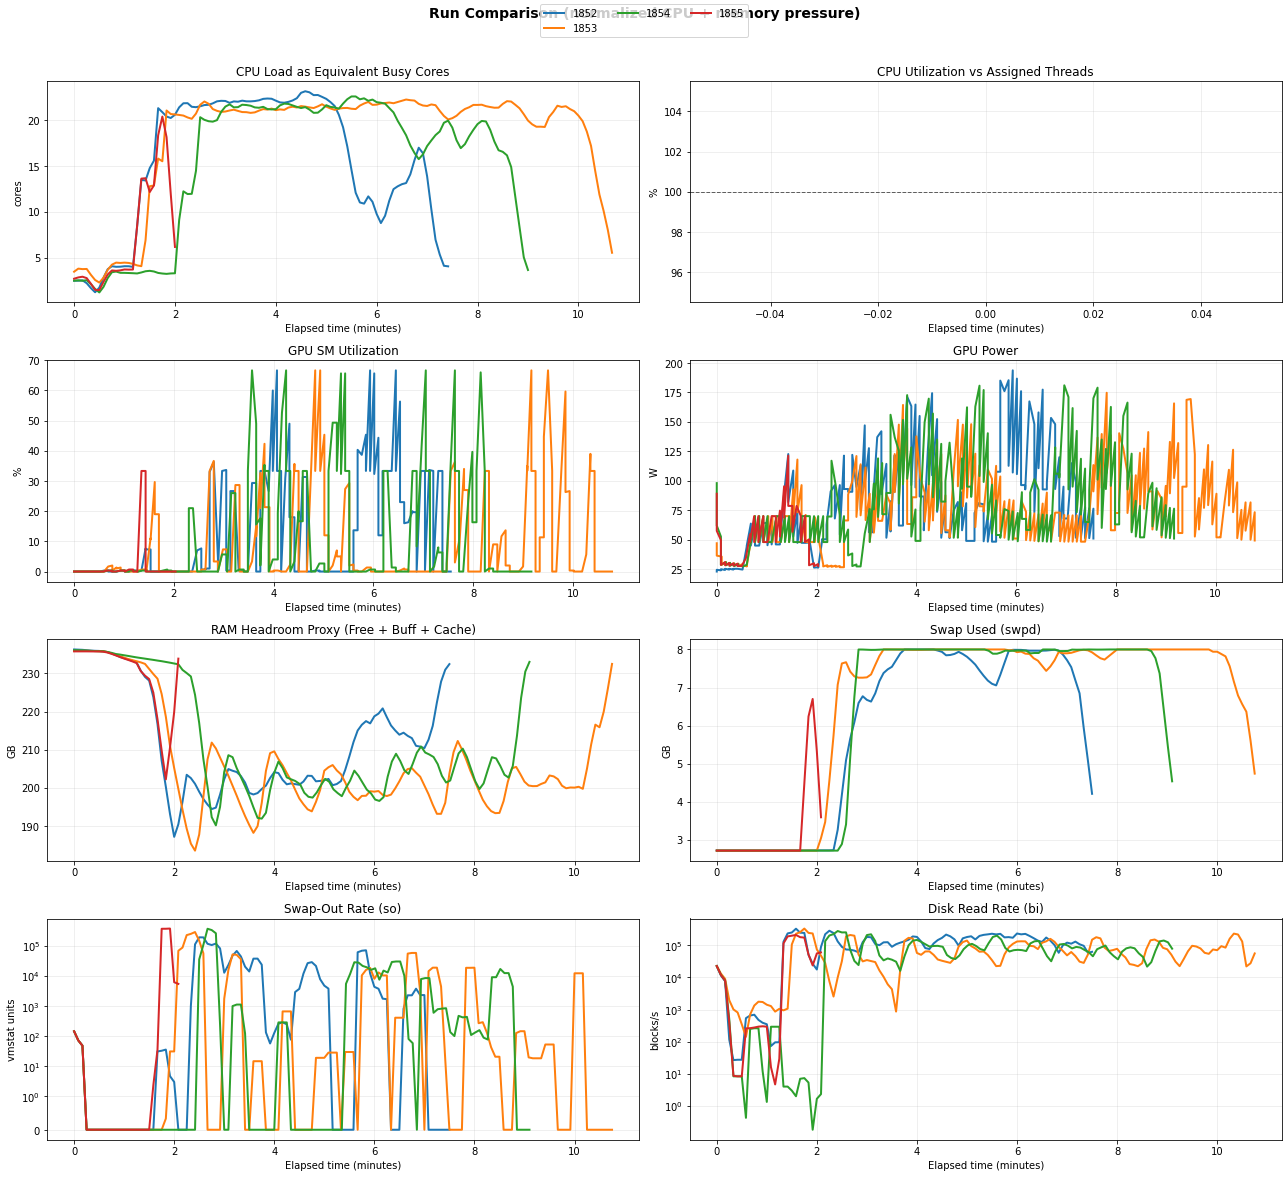

,assigned_threads,duration_min,cpu_busy_mean_cores,cpu_util_vs_assigned_mean_%,cpu_util_vs_assigned_p95_%,gpu_sm_mean_%,gpu_power_mean_W,gpu_vram_peak_GB,headroom_min_GB,swap_used_delta_GB,swap_out_p95,disk_read_peak_bi,memory_pressure_flag
run,,,,,,,,,,,,,
1852,NaN,7.55,15.37,NaN,NaN,12.89,84.03,11.01,182.70,1.18,91630.00,617945,YES
1854,NaN,9.17,15.35,NaN,NaN,10.94,81.92,11.01,183.83,1.40,37627.00,567038,YES
1853,NaN,10.78,18.10,NaN,NaN,8.48,77.21,11.01,182.59,1.22,56730.35,539118,YES
1855,NaN,2.08,7.15,NaN,NaN,2.08,51.12,7.26,193.64,0.09,12802.50,373871,YES


In [1]:
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

MON_DIR = Path("monitoring")

# Option A: auto-compare all runs in monitoring/
RUNS_AUTO = sorted([p.name for p in MON_DIR.iterdir() if p.is_dir()])

# Option B: manually select a subset; set to [] to use RUNS_AUTO
RUNS_SELECTED = [
    "1852", "1853", "1854", "1855"
]

RUNS = RUNS_SELECTED if RUNS_SELECTED else RUNS_AUTO


def parse_total_cores(run_dir: Path) -> float:
    with open(run_dir / "cpu_util.log") as f:
        for line in f:
            m = re.search(r"\((\d+)\s+CPU\)", line)
            if m:
                return float(m.group(1))
    return np.nan


def parse_assigned_threads(run_name: str) -> float:
    # Matches names like "..._6t_...", "..._16t_..."
    m = re.search(r"_(\d+)t(?:_|$)", run_name)
    return float(m.group(1)) if m else np.nan


def parse_cpu(run_dir: Path) -> pd.DataFrame:
    rows = []
    date_str = None

    with open(run_dir / "cpu_util.log") as f:
        for line in f:
            parts = line.split()

            if date_str is None:
                m = re.search(r"\d{2}/\d{2}/\d{4}", line)
                if m:
                    date_str = m.group(0)

            if len(parts) < 9 or parts[2] != "all":
                continue

            try:
                ts = pd.to_datetime(
                    f"{date_str} {parts[0]} {parts[1]}",
                    format="%m/%d/%Y %I:%M:%S %p",
                )
                user = float(parts[3])
                system = float(parts[5])
                iowait = float(parts[6])
                idle = float(parts[8])
                rows.append(
                    {
                        "time": ts,
                        "user": user,
                        "system": system,
                        "iowait": iowait,
                        "idle": idle,
                        "active": 100 - idle,
                    }
                )
            except Exception:
                continue

    df = pd.DataFrame(rows).sort_values("time")
    if df.empty:
        return df

    df["t_min"] = (df["time"] - df["time"].min()).dt.total_seconds() / 60.0
    return df


def parse_gpu(run_dir: Path) -> pd.DataFrame:
    df = pd.read_csv(
        run_dir / "gpu_util.log",
        comment="#",
        sep=r"\s+",
        header=None,
        na_values=["-"],
        names=[
            "date", "time", "gpu", "sm", "mem_pct", "enc", "dec", "jpg",
            "ofa", "pwr", "gtemp", "mtemp", "fb_mb", "bar1", "ccpm", "rxpci", "txpci"
        ],
    )
    if df.empty:
        return df

    df["time"] = pd.to_datetime(
        df["date"].astype(str) + " " + df["time"],
        format="%Y%m%d %H:%M:%S",
    )
    df = df.sort_values("time")
    df["fb_gb"] = df["fb_mb"] / 1024.0
    df["t_min"] = (df["time"] - df["time"].min()).dt.total_seconds() / 60.0
    return df


def parse_mem(run_dir: Path) -> pd.DataFrame:
    rows = []
    with open(run_dir / "memory.log") as f:
        for line in f:
            parts = line.split()
            if len(parts) < 18 or not parts[0].isdigit():
                continue

            try:
                ts = pd.to_datetime(f"{parts[-2]} {parts[-1]}")
                rows.append(
                    {
                        "time": ts,
                        "r": int(parts[0]),
                        "b": int(parts[1]),
                        "swpd_gb": int(parts[2]) / 1024.0**2,
                        "free_gb": int(parts[3]) / 1024.0**2,
                        "buff_gb": int(parts[4]) / 1024.0**2,
                        "cache_gb": int(parts[5]) / 1024.0**2,
                        "si": int(parts[6]),
                        "so": int(parts[7]),
                        "bi": int(parts[8]),
                        "bo": int(parts[9]),
                        "interrupts": int(parts[10]),
                        "cs": int(parts[11]),
                    }
                )
            except Exception:
                continue

    df = pd.DataFrame(rows).sort_values("time")
    if df.empty:
        return df

    df["reclaimable_gb"] = df["buff_gb"] + df["cache_gb"]
    df["headroom_proxy_gb"] = df["free_gb"] + df["reclaimable_gb"]
    df["t_min"] = (df["time"] - df["time"].min()).dt.total_seconds() / 60.0
    return df


missing_runs = []
data = {}
for run in RUNS:
    run_dir = MON_DIR / run

    needed = ["cpu_util.log", "gpu_util.log", "memory.log"]
    if not run_dir.exists() or not all((run_dir / n).exists() for n in needed):
        missing_runs.append(run)
        continue

    cpu = parse_cpu(run_dir)
    gpu = parse_gpu(run_dir)
    mem = parse_mem(run_dir)

    if cpu.empty or gpu.empty or mem.empty:
        missing_runs.append(run)
        continue

    total_cores = parse_total_cores(run_dir)
    assigned_threads = parse_assigned_threads(run)

    cpu["busy_core_eq"] = cpu["active"] * total_cores / 100.0
    cpu["util_vs_assigned_%"] = np.where(
        np.isfinite(assigned_threads) and assigned_threads > 0,
        100.0 * cpu["busy_core_eq"] / assigned_threads,
        np.nan,
    )

    data[run] = {
        "cpu": cpu,
        "gpu": gpu,
        "mem": mem,
        "total_cores": total_cores,
        "assigned_threads": assigned_threads,
    }

print(f"Loaded {len(data)} runs: {', '.join(data.keys())}")
if missing_runs:
    print(f"Skipped runs (missing/incomplete logs): {', '.join(missing_runs)}")


# ----------------------------
# Fair comparison dashboard
# ----------------------------
fig, axes = plt.subplots(4, 2, figsize=(18, 16), sharex=False)
axes = axes.ravel()

for run, d in data.items():
    cpu = d["cpu"]
    gpu = d["gpu"]
    mem = d["mem"]

    # mild smoothing to reduce jitter
    busy_core_eq = cpu["busy_core_eq"].rolling(3, min_periods=1).mean()
    util_vs_assigned = cpu["util_vs_assigned_%"].rolling(3, min_periods=1).mean()
    gpu_sm = gpu["sm"].rolling(3, min_periods=1).mean()
    gpu_pwr = gpu["pwr"].rolling(3, min_periods=1).mean()
    headroom = mem["headroom_proxy_gb"].rolling(3, min_periods=1).mean()
    swpd = mem["swpd_gb"].rolling(3, min_periods=1).mean()
    so = mem["so"].rolling(3, min_periods=1).mean()
    bi = mem["bi"].rolling(3, min_periods=1).mean()

    axes[0].plot(cpu["t_min"], busy_core_eq, label=run, lw=2)
    axes[1].plot(cpu["t_min"], util_vs_assigned, label=run, lw=2)
    axes[2].plot(gpu["t_min"], gpu_sm, label=run, lw=2)
    axes[3].plot(gpu["t_min"], gpu_pwr, label=run, lw=2)
    axes[4].plot(mem["t_min"], headroom, label=run, lw=2)
    axes[5].plot(mem["t_min"], swpd, label=run, lw=2)
    axes[6].plot(mem["t_min"], so, label=run, lw=2)
    axes[7].plot(mem["t_min"], bi, label=run, lw=2)

axes[0].set_title("CPU Load as Equivalent Busy Cores")
axes[1].set_title("CPU Utilization vs Assigned Threads")
axes[2].set_title("GPU SM Utilization")
axes[3].set_title("GPU Power")
axes[4].set_title("RAM Headroom Proxy (Free + Buff + Cache)")
axes[5].set_title("Swap Used (swpd)")
axes[6].set_title("Swap-Out Rate (so)")
axes[7].set_title("Disk Read Rate (bi)")

axes[0].set_ylabel("cores")
axes[1].set_ylabel("%")
axes[2].set_ylabel("%")
axes[3].set_ylabel("W")
axes[4].set_ylabel("GB")
axes[5].set_ylabel("GB")
axes[6].set_ylabel("vmstat units")
axes[7].set_ylabel("blocks/s")

axes[1].axhline(100, color="k", lw=1, ls="--", alpha=0.6)
axes[6].set_yscale("symlog", linthresh=1)
axes[7].set_yscale("symlog", linthresh=1)

for ax in axes:
    ax.set_xlabel("Elapsed time (minutes)")
    ax.grid(alpha=0.25)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=3, frameon=True)
fig.suptitle("Run Comparison (normalized CPU + memory pressure)", y=1.02, fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


# ----------------------------
# Summary table for ranking
# ----------------------------
rows = []
for run, d in data.items():
    cpu = d["cpu"]
    gpu = d["gpu"]
    mem = d["mem"]
    assigned_threads = d["assigned_threads"]

    swpd_delta = mem["swpd_gb"].iloc[-1] - mem["swpd_gb"].iloc[0]
    so_p95 = mem["so"].quantile(0.95)
    pressure_flag = "YES" if (swpd_delta > 0.5 or so_p95 > 0) else "NO"

    rows.append(
        {
            "run": run,
            "assigned_threads": assigned_threads,
            "duration_min": float(max(cpu["t_min"].max(), gpu["t_min"].max(), mem["t_min"].max())),
            "cpu_busy_mean_cores": cpu["busy_core_eq"].mean(),
            "cpu_util_vs_assigned_mean_%": cpu["util_vs_assigned_%"].mean(),
            "cpu_util_vs_assigned_p95_%": cpu["util_vs_assigned_%"].quantile(0.95),
            "gpu_sm_mean_%": gpu["sm"].mean(),
            "gpu_power_mean_W": gpu["pwr"].mean(),
            "gpu_vram_peak_GB": gpu["fb_gb"].max(),
            "headroom_min_GB": mem["headroom_proxy_gb"].min(),
            "swap_used_delta_GB": swpd_delta,
            "swap_out_p95": so_p95,
            "disk_read_peak_bi": mem["bi"].max(),
            "memory_pressure_flag": pressure_flag,
        }
    )

summary = pd.DataFrame(rows).set_index("run").sort_values("gpu_sm_mean_%", ascending=False)
display(summary.round(2))